In [3]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

df = pd.read_parquet("../data/gold/dataset_final.parquet")

df.head()

,fecha,eolica,generacion_renovable_total,hidraulica,hidroeolica,otras_renovables,residuos_renovables,solar_fotovoltaica,solar_termica,year,...,festivo_nombre,festivo_nacional,es_festivo,dia_semana,nombre_dia,fin_de_semana,mes,trimestre,dia_del_ano,temp_x_festivo
0,2024-01-01,159629.924,296067.656,58381.148,3.650,6171.128,2470.343,66642.505,2768.958,2024,...,Año Nuevo,1,1,0,Monday,0,1,1,1,9.207096
1,2024-01-02,307120.989,436751.715,68004.167,2.920,6820.630,2427.951,49615.015,2760.043,2024,...,No festivo,0,0,1,Tuesday,0,1,1,2,0.000000
2,2024-01-03,284990.434,426342.548,93862.430,3.037,7570.068,2412.098,36440.805,1063.676,2024,...,No festivo,0,0,2,Wednesday,0,1,1,3,0.000000
3,2024-01-04,138827.131,315220.327,139605.013,9.976,8209.237,2548.542,26019.065,1.363,2024,...,No festivo,0,0,3,Thursday,0,1,1,4,0.000000
4,2024-01-05,306634.568,464836.559,83467.494,7.722,8140.782,2421.029,61906.689,2258.275,2024,...,No festivo,0,0,4,Friday,0,1,1,5,0.000000


In [6]:
print(df["fecha"].min(), df["fecha"].max())
print(df["fecha"].nunique())

2024-01-01 00:00:00 2025-12-31 00:00:00
731


# ***Evolución de la generación renovable total***

In [13]:
pio.renderers.default = "iframe" 

fig1 = px.line(
    df,
    x="fecha",
    y="generacion_renovable_total",
    title="Evolución de la generación renovable total en España"
)

fig1.show()

La generación renovable presenta una alta variabilidad diaria, lo que refleja la dependencia de factores externos como las condiciones meteorológicas.

## ***CLIMA vs ENERGÍA***

In [7]:
fig = px.scatter(
    df,
    x="viento",
    y="eolica",
    title="Relación entre viento y energía eólica"
)
fig.show()

Existe una fuerte relación positiva entre la velocidad del viento y la generación de energía eólica.

In [8]:
fig = px.scatter(
    df,
    x="temperatura_media",
    y="solar_fotovoltaica",
    title="Temperatura vs energía solar"
)
fig.show()

La generación solar aumenta con la temperatura, pero la relación es moderada y no perfectamente lineal, ya que también depende de factores como radiación solar y nubosidad.

## ***FESTIVOS vs ENERGÍA***

In [9]:
df_fest = df.groupby("es_festivo")["generacion_renovable_total"].mean().reset_index()

px.bar(df_fest, x="es_festivo", y="generacion_renovable_total").show()

La generación renovable no depende del comportamiento humano, sino de condiciones naturales, por lo que los festivos no tienen un impacto significativo.

## ***PATRONES TEMPORALES***

### **Mes**

In [10]:
df_mes = df.groupby("mes")["generacion_renovable_total"].mean().reset_index()

px.line(df_mes, x="mes", y="generacion_renovable_total").show()

Existen patrones estacionales, con mayor generación en primavera, probablemente debido a mejores condiciones de viento y radiación solar.

### **Día de la semana**

In [11]:
df_dia = df.groupby("dia_semana")["generacion_renovable_total"].mean().reset_index()

px.bar(df_dia, x="dia_semana", y="generacion_renovable_total").show()

No hay diferencias significativas entre días de la semana, lo que confirma que la generación depende del clima y no del calendario laboral.

## ***CORRELACIONES***

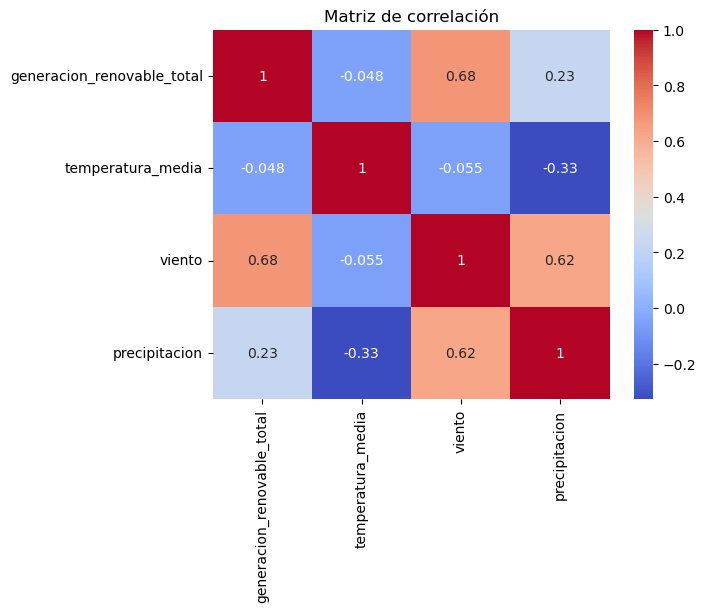

In [12]:
corr = df[[
    "generacion_renovable_total",
    "temperatura_media",
    "viento",
    "precipitacion"
]].corr()

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

El viento es el factor más determinante en la generación renovable, mientras que la temperatura tiene un impacto limitado.

## ***CONCLUSIÓN FINAL***
- Después de analizar los datos, hemos visto que la energía renovable depende sobre todo del clima, especialmente del viento.
- Factores como los festivos o los días de la semana no influyen prácticamente nada.
- También hemos visto que hay épocas del año donde se produce más energía que en otras.
- En resumen, la generación de energía renovable está marcada por la naturaleza, no por el comportamiento humano.

Esto demuestra que, si queremos predecir la energía renovable, lo más importante es tener en cuenta el clima.